In [5]:
import sys

print(sys.executable)
print(sys.version)

d:\Portfolio\AI-Investment-Decision-Engine\venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [6]:
from dotenv import load_dotenv, find_dotenv
import os

dotenv_path = find_dotenv()

print("ENV PATH:")
print(dotenv_path)

load_dotenv(dotenv_path)

API_KEY = os.getenv("FMP_API_KEY")

print("KEY FOUND:")
print(API_KEY is not None)

if API_KEY:
    print(API_KEY[:5])

ENV PATH:
d:\Portfolio\AI-Investment-Decision-Engine\.env
KEY FOUND:
True
FxSUX


In [7]:
import requests

symbol = "AAPL"

url = (
    f"https://financialmodelingprep.com/stable/profile"
    f"?symbol={symbol}&apikey={API_KEY}"
)

response = requests.get(url)

print(response.status_code)

data = response.json()

data

200


[{'symbol': 'AAPL',
  'price': 333.74,
  'marketCap': 4901758191440,
  'beta': 1.097,
  'lastDividend': 1.05,
  'range': '201.5-334.99',
  'change': 0.48,
  'changePercentage': 0.14403,
  'volume': 63407059,
  'averageVolume': 54830800,
  'companyName': 'Apple Inc.',
  'currency': 'USD',
  'cik': '0000320193',
  'isin': 'US0378331005',
  'cusip': '037833100',
  'exchangeFullName': 'NASDAQ Global Select',
  'exchange': 'NASDAQ',
  'industry': 'Consumer Electronics',
  'website': 'https://www.apple.com',
  'description': "Apple Inc. is a global technology corporation that specializes in the conceptualization, production, and sale of a diverse suite of electronic devices. Its comprehensive hardware lineup features the well-known iPhone smartphones, Mac personal computers, and versatile iPad tablets. The company also supplies a range of wearables, smart home products, and accessories, including AirPods, Apple TV, Apple Watch, items from the Beats brand, and HomePod speakers. Beyond its dev

In [8]:
import sys

sys.path.append("../")

from src.fmp_client import FMPClient


client = FMPClient(API_KEY)

In [9]:
apple_profile = client.get_profile("AAPL")

apple_profile

[{'symbol': 'AAPL',
  'price': 333.74,
  'marketCap': 4901758191440,
  'beta': 1.097,
  'lastDividend': 1.05,
  'range': '201.5-334.99',
  'change': 0.48,
  'changePercentage': 0.14403,
  'volume': 63407059,
  'averageVolume': 54830800,
  'companyName': 'Apple Inc.',
  'currency': 'USD',
  'cik': '0000320193',
  'isin': 'US0378331005',
  'cusip': '037833100',
  'exchangeFullName': 'NASDAQ Global Select',
  'exchange': 'NASDAQ',
  'industry': 'Consumer Electronics',
  'website': 'https://www.apple.com',
  'description': "Apple Inc. is a global technology corporation that specializes in the conceptualization, production, and sale of a diverse suite of electronic devices. Its comprehensive hardware lineup features the well-known iPhone smartphones, Mac personal computers, and versatile iPad tablets. The company also supplies a range of wearables, smart home products, and accessories, including AirPods, Apple TV, Apple Watch, items from the Beats brand, and HomePod speakers. Beyond its dev

In [10]:
companies = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA",
    "META",
    "TSLA",
    "JPM",
    "BAC",
    "V"
]

In [11]:
financial_data = []

for symbol in companies:
    
    print(f"Downloading {symbol}...")
    
    try:
        profile = client.get_profile(symbol)
        income = client.get_income_statement(symbol)
        balance = client.get_balance_sheet(symbol)
        cashflow = client.get_cash_flow(symbol)
        ratios = client.get_ratios(symbol)

        financial_data.append({
            "symbol": symbol,
            "profile": profile,
            "income": income,
            "balance": balance,
            "cashflow": cashflow,
            "ratios": ratios
        })

    except Exception as e:
        print(f"Error with {symbol}: {e}")

In [12]:
import os

os.makedirs("../data", exist_ok=True)

print("data folder ready")


import json

with open(
    "../data/raw_financial_data.json",
    "w"
) as f:
    
    json.dump(
        financial_data,
        f,
        indent=4
    )

data folder ready


In [13]:
import json
import pandas as pd


with open(
    "../data/raw_financial_data.json",
    "r"
) as f:
    
    raw_data = json.load(f)


print(len(raw_data))

10


In [14]:
raw_data[0]["symbol"]

'AAPL'

In [15]:
raw_data[0]["income"][0]

{'date': '2025-09-27',
 'symbol': 'AAPL',
 'reportedCurrency': 'USD',
 'cik': '0000320193',
 'filingDate': '2025-10-31',
 'acceptedDate': '2025-10-31 06:01:26',
 'fiscalYear': '2025',
 'period': 'FY',
 'revenue': 416161000000,
 'costOfRevenue': 220960000000,
 'grossProfit': 195201000000,
 'researchAndDevelopmentExpenses': 34550000000,
 'generalAndAdministrativeExpenses': 27601000000,
 'sellingAndMarketingExpenses': 0,
 'sellingGeneralAndAdministrativeExpenses': 27601000000,
 'otherExpenses': 0,
 'operatingExpenses': 62151000000,
 'costAndExpenses': 283111000000,
 'netInterestIncome': 0,
 'interestIncome': 0,
 'interestExpense': 0,
 'depreciationAndAmortization': 11698000000,
 'ebitda': 144427000000,
 'ebit': 132729000000,
 'nonOperatingIncomeExcludingInterest': 321000000,
 'operatingIncome': 133050000000,
 'totalOtherIncomeExpensesNet': -321000000,
 'incomeBeforeTax': 132729000000,
 'incomeTaxExpense': 20719000000,
 'netIncomeFromContinuingOperations': 112010000000,
 'netIncomeFromDisc

In [16]:
def extract_features(company):

    profile = company["profile"][0]
    income = company["income"][0]
    ratios = company["ratios"][0]


    features = {

        # Identity
        "symbol": company["symbol"],

        # Company
        "companyName": profile.get("companyName"),
        "sector": profile.get("sector"),
        "industry": profile.get("industry"),

        # Market
        "marketCap": profile.get("marketCap"),
        "beta": profile.get("beta"),
        "price": profile.get("price"),


        # Income
        "revenue": income.get("revenue"),
        "grossProfit": income.get("grossProfit"),
        "ebitda": income.get("ebitda"),
        "operatingIncome": income.get("operatingIncome"),
        "netIncome": income.get("netIncome"),
        "eps": income.get("eps"),


        # Profitability
        "grossMargin": ratios.get("grossProfitMargin"),
        "ebitMargin": ratios.get("ebitMargin"),
        "ebitdaMargin": ratios.get("ebitdaMargin"),
        "operatingMargin": ratios.get("operatingProfitMargin"),
        "netMargin": ratios.get("netProfitMargin"),


        # Valuation
        "peRatio": ratios.get("priceToEarningsRatio"),
        "pegRatio": ratios.get("priceToEarningsGrowthRatio"),
        "pbRatio": ratios.get("priceToBookRatio"),
        "psRatio": ratios.get("priceToSalesRatio"),
        "fcfMultiple": ratios.get("priceToFreeCashFlowRatio"),


        # Liquidity
        "currentRatio": ratios.get("currentRatio"),
        "quickRatio": ratios.get("quickRatio"),
        "cashRatio": ratios.get("cashRatio"),


        # Debt
        "debtAssets": ratios.get("debtToAssetsRatio"),
        "debtEquity": ratios.get("debtToEquityRatio"),
        "financialLeverage": ratios.get("financialLeverageRatio"),


        # Efficiency
        "assetTurnover": ratios.get("assetTurnover"),
        "inventoryTurnover": ratios.get("inventoryTurnover"),
        "receivablesTurnover": ratios.get("receivablesTurnover"),


        # Cash Flow
        "operatingCashFlowSales": ratios.get("operatingCashFlowSalesRatio"),
        "freeCashFlowQuality": ratios.get("freeCashFlowOperatingCashFlowRatio"),
        "freeCashFlowPerShare": ratios.get("freeCashFlowPerShare"),

    }


    return features

In [17]:
features_list = []

for company in raw_data:
    features_list.append(
        extract_features(company)
    )


df_features = pd.DataFrame(features_list)

df_features.shape

(10, 35)

In [18]:
df_features.to_csv(
    "../data/financial_features.csv",
    index=False
)

In [19]:
import numpy as np

df = df_features.copy()


df["quality_score"] = (

    df["netMargin"].rank(pct=True)

    +

    df["ebitdaMargin"].rank(pct=True)

    +

    df["operatingMargin"].rank(pct=True)

    +

    df["currentRatio"].rank(pct=True)

    -

    df["debtEquity"].rank(pct=True)

    -

    df["peRatio"].rank(pct=True)

)


df["quality_score"] = (
    df["quality_score"]
    /
    df["quality_score"].max()
)


df[[
    "symbol",
    "quality_score"
]].sort_values(
    "quality_score",
    ascending=False
)

,symbol,quality_score
4,NVDA,1.000000e+00
5,META,6.666667e-01
2,GOOGL,6.333333e-01
9,V,6.333333e-01
1,MSFT,6.000000e-01
7,JPM,6.666667e-02
0,AAPL,6.666667e-02
3,AMZN,3.333333e-02
8,BAC,-9.251859e-18
6,TSLA,-3.333333e-02


In [20]:
df["Target"] = (
    df["quality_score"] >
    df["quality_score"].median()
).astype(int)


df[
    [
        "symbol",
        "quality_score",
        "Target"
    ]
].sort_values(
    "quality_score",
    ascending=False
)

,symbol,quality_score,Target
4,NVDA,1.000000e+00,1
5,META,6.666667e-01,1
2,GOOGL,6.333333e-01,1
9,V,6.333333e-01,1
1,MSFT,6.000000e-01,1
7,JPM,6.666667e-02,0
0,AAPL,6.666667e-02,0
3,AMZN,3.333333e-02,0
8,BAC,-9.251859e-18,0
6,TSLA,-3.333333e-02,0


In [21]:
df.to_csv(
    "../data/ml_dataset.csv",
    index=False
)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


target = "Target"


X = df.drop(
    columns=[
        "symbol",
        "companyName",
        "sector",
        "industry",
        "Target"
    ]
)


y = df[target]


print(X.shape)
print(y.shape)

(10, 32)
(10,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [24]:
model = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "classifier",
        LogisticRegression()
    )
])


model.fit(
    X_train,
    y_train
)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]


print(
    "Accuracy:",
    accuracy_score(y_test,pred)
)

print(
    "Precision:",
    precision_score(y_test,pred)
)

print(
    "Recall:",
    recall_score(y_test,pred)
)

print(
    "F1:",
    f1_score(y_test,pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test,prob)
)


print(
    confusion_matrix(
        y_test,
        pred
    )
)

Accuracy: 0.6666666666666666
Precision: 0.5
Recall: 1.0
F1: 0.6666666666666666
ROC AUC: 1.0
[[1 1]
 [0 1]]


#### RANDOM FOREST

In [26]:
from sklearn.ensemble import RandomForestClassifier


rf_model = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])


rf_model.fit(
    X_train,
    y_train
)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [27]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]


print(
    "Accuracy:",
    accuracy_score(y_test,rf_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test,rf_prob)
)

print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

Accuracy: 0.6666666666666666
ROC AUC: 1.0
[[1 1]
 [0 1]]


##### XGBoost + Feature Importance + Investment Ranking

In [28]:
from xgboost import XGBClassifier


xgb_model = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    )
])


xgb_model.fit(
    X_train,
    y_train
)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                         

In [29]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]


print(
    "Accuracy:",
    accuracy_score(y_test,xgb_pred)
)


print(
    "ROC AUC:",
    roc_auc_score(y_test,xgb_prob)
)


print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

Accuracy: 0.3333333333333333
ROC AUC: 0.5
[[0 2]
 [0 1]]


In [30]:
import pandas as pd


importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model
        .named_steps["classifier"]
        .feature_importances_

})


importance.sort_values(
    "Importance",
    ascending=False
).head(15)

,Feature,Importance
10,ebitMargin,0.081633
28,operatingCashFlowSales,0.081633
13,netMargin,0.071429
12,operatingMargin,0.069898
30,freeCashFlowPerShare,0.066327
31,quality_score,0.061224
6,operatingIncome,0.056122
9,grossMargin,0.053401
11,ebitdaMargin,0.048151
0,marketCap,0.045918


In [31]:
all_prob = rf_model.predict_proba(X)[:,1]

ranking = df[
    ["symbol"]
].copy()

ranking["ML_Probability"] = all_prob

ranking["Signal"] = np.where(
    ranking["ML_Probability"] >= 0.5,
    "BUY",
    "HOLD"
)


ranking.sort_values(
    "ML_Probability",
    ascending=False
)

,symbol,ML_Probability,Signal
2,GOOGL,0.970,BUY
1,MSFT,0.940,BUY
4,NVDA,0.940,BUY
5,META,0.880,BUY
9,V,0.705,BUY
0,AAPL,0.645,BUY
7,JPM,0.445,HOLD
3,AMZN,0.165,HOLD
6,TSLA,0.145,HOLD
8,BAC,0.125,HOLD


In [32]:
import shap

d:\Portfolio\AI-Investment-Decision-Engine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
import matplotlib.pyplot as plt

In [34]:
rf_classifier = rf_model.named_steps["classifier"]

In [35]:
explainer = shap.TreeExplainer(
    rf_classifier
)

In [36]:
X_scaled = rf_model.named_steps["scaler"].transform(X)

In [37]:
shap_values = explainer.shap_values(
    X_scaled
)

In [38]:
import numpy as np

print(np.array(shap_values).shape)
print(X_scaled.shape)

(10, 32, 2)
(10, 32)


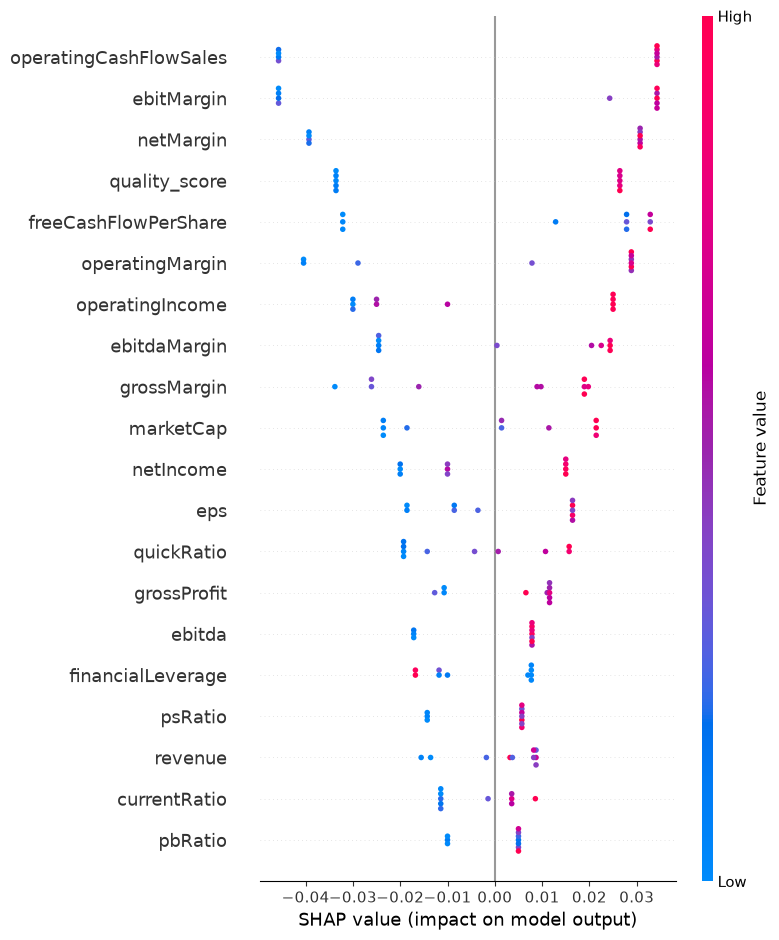

In [39]:
shap_values_class1 = shap_values[:, :, 1]


shap.summary_plot(
    shap_values_class1,
    X_scaled,
    feature_names=X.columns
)

In [40]:
df.to_csv(
    "../data/ml_dataset.csv",
    index=False
)

print("saved")

saved


#### Backtesting Engine.

In [41]:
import os
import requests
import pandas as pd
import json
from datetime import datetime

In [42]:
API_KEY = os.getenv("FMP_API_KEY")


def get_price_history(symbol):

    url = (
        f"https://financialmodelingprep.com/stable/historical-price-eod/full"
        f"?symbol={symbol}"
        f"&apikey={API_KEY}"
    )


    response = requests.get(url)

    data = response.json()

    return data

In [43]:
prices_aapl = get_price_history("AAPL")

prices_aapl[:2]

[{'symbol': 'AAPL',
  'date': '2026-07-17',
  'open': 331.98,
  'high': 334.99,
  'low': 329,
  'close': 333.74,
  'volume': 63407059,
  'change': 1.76,
  'changePercent': 0.53015,
  'vwap': 332.4275},
 {'symbol': 'AAPL',
  'date': '2026-07-16',
  'open': 328.01,
  'high': 334.68,
  'low': 326.79,
  'close': 333.26,
  'volume': 62970617,
  'change': 5.25,
  'changePercent': 1.6,
  'vwap': 330.685}]

In [44]:
symbols = ranking["symbol"].tolist()

symbols

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'BAC', 'V']

In [45]:
all_prices = []


for symbol in symbols:

    print(symbol)

    data = get_price_history(symbol)

    for row in data:

        row["symbol"] = symbol

        all_prices.append(row)

AAPL
MSFT
GOOGL
AMZN
NVDA
META
TSLA
JPM
BAC
V


In [46]:
prices_df = pd.DataFrame(all_prices)


prices_df.head()

,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,AAPL,2026-07-17,331.98,334.99,329.00,333.74,63407059,1.760,0.530150,332.4275
1,AAPL,2026-07-16,328.01,334.68,326.79,333.26,62970617,5.250,1.600000,330.6850
2,AAPL,2026-07-15,317.62,328.73,317.32,327.50,60957644,9.880,3.110000,322.7925
3,AAPL,2026-07-14,313.76,316.19,311.91,314.86,36336829,1.100,0.350590,314.1800
4,AAPL,2026-07-13,317.02,323.45,315.78,317.31,43257804,0.295,0.091477,318.3900


In [47]:
prices_df.to_csv(
    "../data/historical_prices.csv",
    index=False
)


print(
    prices_df.shape
)

(12530, 10)


In [48]:
prices_aapl = get_price_history("AAPL")

prices_aapl[:2]

[{'symbol': 'AAPL',
  'date': '2026-07-17',
  'open': 331.98,
  'high': 334.99,
  'low': 329,
  'close': 333.74,
  'volume': 63407059,
  'change': 1.76,
  'changePercent': 0.53015,
  'vwap': 332.4275},
 {'symbol': 'AAPL',
  'date': '2026-07-16',
  'open': 328.01,
  'high': 334.68,
  'low': 326.79,
  'close': 333.26,
  'volume': 62970617,
  'change': 5.25,
  'changePercent': 1.6,
  'vwap': 330.685}]

In [49]:
buy_list = ranking[
    ranking["Signal"]=="BUY"
]["symbol"].tolist()


buy_list

['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META', 'V']

In [50]:
portfolio_prices = prices_df[
    prices_df["symbol"].isin(buy_list)
].copy()


portfolio_prices.head()

,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,AAPL,2026-07-17,331.98,334.99,329.00,333.74,63407059,1.760,0.530150,332.4275
1,AAPL,2026-07-16,328.01,334.68,326.79,333.26,62970617,5.250,1.600000,330.6850
2,AAPL,2026-07-15,317.62,328.73,317.32,327.50,60957644,9.880,3.110000,322.7925
3,AAPL,2026-07-14,313.76,316.19,311.91,314.86,36336829,1.100,0.350590,314.1800
4,AAPL,2026-07-13,317.02,323.45,315.78,317.31,43257804,0.295,0.091477,318.3900


In [51]:
price_matrix = (
    portfolio_prices
    .pivot(
        index="date",
        columns="symbol",
        values="close"
    )
)


price_matrix.head()

symbol,AAPL,GOOGL,META,MSFT,NVDA,V
date,,,,,,
2021-07-21,145.40,127.55,346.23,281.40,19.41,243.66
2021-07-22,146.80,128.42,351.19,286.14,19.59,244.14
2021-07-23,148.56,133.01,369.79,289.67,19.56,249.02
2021-07-26,148.99,134.04,372.46,289.05,19.29,250.25
2021-07-27,146.77,131.90,367.81,286.54,19.21,250.93


In [52]:
daily_returns = (
    price_matrix
    .pct_change()
    .dropna()
)


daily_returns.head()

symbol,AAPL,GOOGL,META,MSFT,NVDA,V
date,,,,,,
2021-07-22,0.009629,0.006821,0.014326,0.016844,0.009274,0.001970
2021-07-23,0.011989,0.035742,0.052963,0.012337,-0.001531,0.019989
2021-07-26,0.002894,0.007744,0.007220,-0.002140,-0.013804,0.004939
2021-07-27,-0.014900,-0.015965,-0.012485,-0.008684,-0.004147,0.002717
2021-07-28,-0.012196,0.031766,0.014872,-0.001117,0.015096,-0.015901


In [53]:
print(daily_returns.shape)
print(daily_returns.head())

(1252, 6)
symbol          AAPL     GOOGL      META      MSFT      NVDA         V
date                                                                  
2021-07-22  0.009629  0.006821  0.014326  0.016844  0.009274  0.001970
2021-07-23  0.011989  0.035742  0.052963  0.012337 -0.001531  0.019989
2021-07-26  0.002894  0.007744  0.007220 -0.002140 -0.013804  0.004939
2021-07-27 -0.014900 -0.015965 -0.012485 -0.008684 -0.004147  0.002717
2021-07-28 -0.012196  0.031766  0.014872 -0.001117  0.015096 -0.015901


In [54]:
# AI Portfolio daily returns

portfolio_return = (
    daily_returns.mean(axis=1)
)


portfolio_return.name = "AI Portfolio"


portfolio_return.head()

date
2021-07-22    0.009811
2021-07-23    0.021915
2021-07-26    0.001142
2021-07-27   -0.008911
2021-07-28    0.005420
Name: AI Portfolio, dtype: float64

In [55]:
import numpy as np


target_vol = 0.15


current_vol = (
    portfolio_return.std()
    *
    np.sqrt(252)
)


scaling_factor = (
    target_vol /
    current_vol
)


risk_adjusted_returns = (
    portfolio_return *
    scaling_factor
)


print("Current volatility:", current_vol)
print("Scaling factor:", scaling_factor)


risk_adjusted_returns.head()

Current volatility: 0.26123658890539597
Scaling factor: 0.5741921551973751


date
2021-07-22    0.005633
2021-07-23    0.012583
2021-07-26    0.000656
2021-07-27   -0.005116
2021-07-28    0.003112
Name: AI Portfolio, dtype: float64

In [66]:
spy_prices = get_price_history(
    "SPY"
)


spy_df = pd.DataFrame(
    spy_prices
)


spy_df["date"] = pd.to_datetime(
    spy_df["date"]
)


# Sort SPY chronologically

spy_df = (
    spy_df
    .sort_values(
        "date"
    )
)


spy_returns = (
    spy_df
    .set_index("date")["close"]
    .pct_change()
    .dropna()
)


spy_returns.head()


spy_returns.head()

date
2021-07-22    0.002094
2021-07-23    0.010288
2021-07-26    0.002455
2021-07-27   -0.004558
2021-07-28   -0.000410
Name: close, dtype: float64

In [67]:
risk_adjusted_returns.index = pd.to_datetime(
    risk_adjusted_returns.index
)


common_dates = (
    risk_adjusted_returns.index
    .intersection(
        spy_returns.index
    )
)


ai_returns_aligned = (
    risk_adjusted_returns
    .loc[common_dates]
)


spy_returns_aligned = (
    spy_returns
    .loc[common_dates]
)


print(ai_returns_aligned.shape)
print(spy_returns_aligned.shape)

(1252,)
(1252,)


In [68]:
# Build equity curves

ai_curve = (
    1 + ai_returns_aligned
).cumprod()


spy_curve = (
    1 + spy_returns_aligned
).cumprod()


print(ai_curve.head())
print(spy_curve.head())

date
2021-07-22    1.005633
2021-07-23    1.018287
2021-07-26    1.018955
2021-07-27    1.013742
2021-07-28    1.016897
Name: AI Portfolio, dtype: float64
date
2021-07-22    1.002094
2021-07-23    1.012404
2021-07-26    1.014889
2021-07-27    1.010263
2021-07-28    1.009849
Name: close, dtype: float64


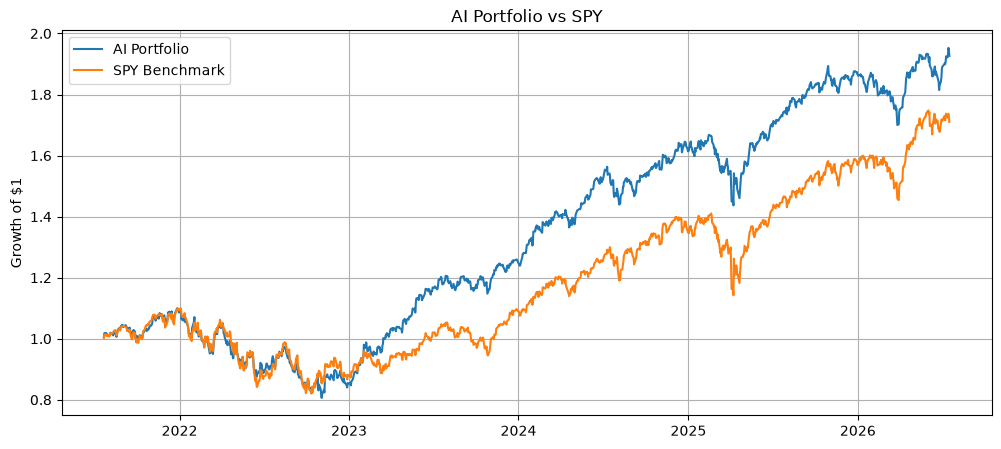

In [69]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))


plt.plot(
    ai_curve.index,
    ai_curve.values,
    label="AI Portfolio"
)


plt.plot(
    spy_curve.index,
    spy_curve.values,
    label="SPY Benchmark"
)


plt.title(
    "AI Portfolio vs SPY"
)


plt.ylabel(
    "Growth of $1"
)


plt.legend()

plt.grid()

plt.show()

In [70]:
# Drawdown calculation

ai_drawdown = (
    ai_curve /
    ai_curve.cummax()
) - 1


spy_drawdown = (
    spy_curve /
    spy_curve.cummax()
) - 1


print(ai_drawdown.min())
print(spy_drawdown.min())

-0.26712539754247844
-0.2536057440706697


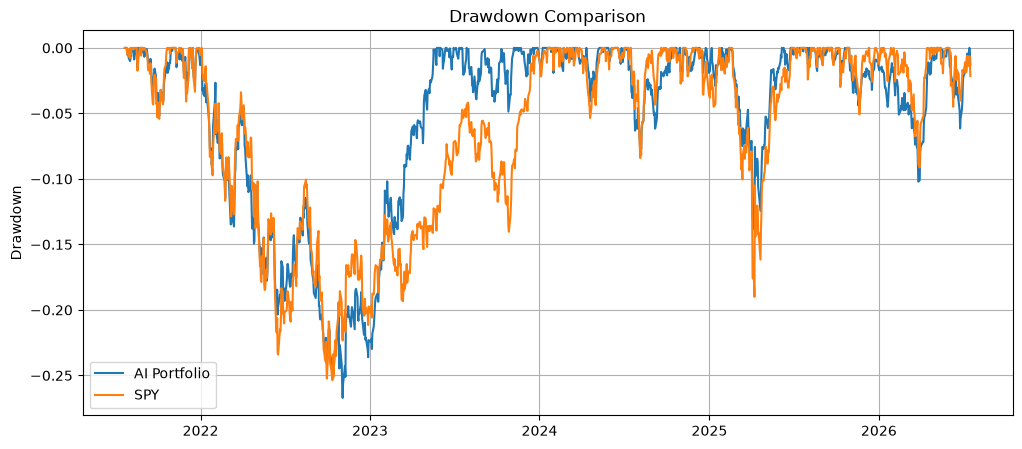

In [71]:
plt.figure(figsize=(12,5))


plt.plot(
    ai_drawdown.index,
    ai_drawdown.values,
    label="AI Portfolio"
)


plt.plot(
    spy_drawdown.index,
    spy_drawdown.values,
    label="SPY"
)


plt.title(
    "Drawdown Comparison"
)


plt.ylabel(
    "Drawdown"
)


plt.legend()

plt.grid()

plt.show()

In [72]:
def performance_metrics(returns):

    annual_return = (
        (1 + returns).prod()
        **
        (252 / len(returns))
    ) - 1


    annual_volatility = (
        returns.std()
        *
        np.sqrt(252)
    )


    sharpe = (
        annual_return /
        annual_volatility
    )


    curve = (
        1 + returns
    ).cumprod()


    drawdown = (
        curve /
        curve.cummax()
    ) - 1


    max_drawdown = (
        drawdown.min()
    )


    return {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown
    }

In [73]:
results = pd.DataFrame(
    {
        "AI Portfolio":
            performance_metrics(ai_returns_aligned),

        "SPY":
            performance_metrics(spy_returns_aligned)
    }
).T


results

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
AI Portfolio,0.141118,0.150000,0.940783,-0.267125
SPY,0.114093,0.171997,0.663345,-0.253606


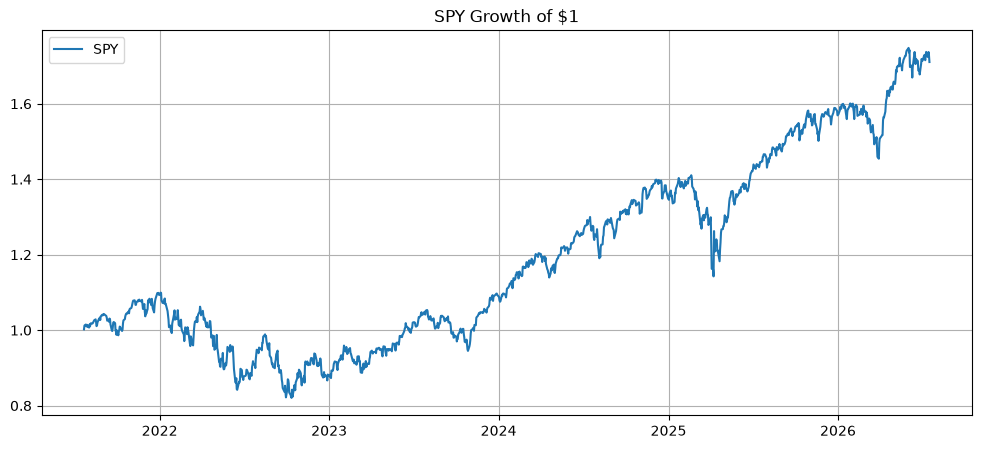

In [74]:
plt.figure(figsize=(12,5))

plt.plot(
    spy_curve.index,
    spy_curve.values,
    label="SPY"
)

plt.title("SPY Growth of $1")

plt.legend()

plt.grid()

plt.show()

In [75]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)


pd.DataFrame({
    "AI Portfolio": ai_curve,
    "SPY": spy_curve
}).to_csv(
    "../data/processed/equity_curves.csv"
)


results.to_csv(
    "../data/processed/performance_metrics.csv"
)


ai_returns_aligned.to_csv(
    "../data/processed/ai_returns.csv"
)


spy_returns_aligned.to_csv(
    "../data/processed/spy_returns.csv"
)


print("Export completed")

Export completed


In [77]:
import pandas as pd

ml_signals = pd.DataFrame(
    {
        "symbol": [
            "GOOGL",
            "MSFT",
            "NVDA",
            "META",
            "V",
            "AAPL",
            "JPM",
            "AMZN",
            "TSLA",
            "BAC"
        ],
        "ML_Probability": [
            0.970,
            0.940,
            0.940,
            0.880,
            0.705,
            0.645,
            0.445,
            0.165,
            0.145,
            0.125
        ],
        "Signal": [
            "BUY",
            "BUY",
            "BUY",
            "BUY",
            "BUY",
            "BUY",
            "HOLD",
            "HOLD",
            "HOLD",
            "HOLD"
        ]
    }
)


ml_signals.to_csv(
    "../data/processed/ml_signals.csv",
    index=False
)


ml_signals

,symbol,ML_Probability,Signal
0,GOOGL,0.970,BUY
1,MSFT,0.940,BUY
2,NVDA,0.940,BUY
3,META,0.880,BUY
4,V,0.705,BUY
5,AAPL,0.645,BUY
6,JPM,0.445,HOLD
7,AMZN,0.165,HOLD
8,TSLA,0.145,HOLD
9,BAC,0.125,HOLD


In [78]:
feature_importance = pd.DataFrame(
    {
        "Feature": [
            "ebitMargin",
            "operatingCashFlowSales",
            "netMargin",
            "operatingMargin",
            "freeCashFlowPerShare",
            "quality_score",
            "operatingIncome",
            "grossMargin",
            "ebitdaMargin",
            "marketCap"
        ],
        "Importance": [
            0.081633,
            0.081633,
            0.071429,
            0.069898,
            0.066327,
            0.061224,
            0.056122,
            0.053401,
            0.048151,
            0.045918
        ]
    }
)


feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)


feature_importance

,Feature,Importance
0,ebitMargin,0.081633
1,operatingCashFlowSales,0.081633
2,netMargin,0.071429
3,operatingMargin,0.069898
4,freeCashFlowPerShare,0.066327
5,quality_score,0.061224
6,operatingIncome,0.056122
7,grossMargin,0.053401
8,ebitdaMargin,0.048151
9,marketCap,0.045918


In [79]:
print("model" in globals())
print("X_test" in globals())

True
True


In [92]:
id="x9k2lm"
print(df_features.columns.tolist())

['symbol', 'companyName', 'sector', 'industry', 'marketCap', 'beta', 'price', 'revenue', 'grossProfit', 'ebitda', 'operatingIncome', 'netIncome', 'eps', 'grossMargin', 'ebitMargin', 'ebitdaMargin', 'operatingMargin', 'netMargin', 'peRatio', 'pegRatio', 'pbRatio', 'psRatio', 'fcfMultiple', 'currentRatio', 'quickRatio', 'cashRatio', 'debtAssets', 'debtEquity', 'financialLeverage', 'assetTurnover', 'inventoryTurnover', 'receivablesTurnover', 'operatingCashFlowSales', 'freeCashFlowQuality', 'freeCashFlowPerShare']


In [81]:
import shap
import pandas as pd
import numpy as np


# Get final model inside pipeline

classifier = model.steps[-1][1]


print(classifier)

LogisticRegression()


In [93]:
import shap
import pandas as pd


# Τα features ακριβώς όπως τα είδε το μοντέλο

feature_columns = X_train.columns


X_all = df_features.copy()


# Προσθέτουμε quality_score αν λείπει
if "quality_score" not in X_all.columns:

    X_all["quality_score"] = (
        df_features["quality_score"]
        if "quality_score" in df_features.columns
        else 0
    )


# Κρατάμε μόνο τα training features
X_all = X_all[
    feature_columns
]


# Pipeline components

classifier = model.named_steps[
    "classifier"
]


scaler = model.named_steps[
    "scaler"
]


# Scaling

X_scaled = scaler.transform(
    X_all
)


# SHAP

explainer = shap.LinearExplainer(
    classifier,
    X_scaled
)


shap_values = explainer.shap_values(
    X_scaled
)


# Create dataframe

shap_all_df = pd.DataFrame(
    shap_values,
    columns=feature_columns
)


shap_all_df["symbol"] = (
    df_features["symbol"]
    .values
)


shap_all_df.to_csv(
    "../data/processed/shap_values.csv",
    index=False
)


shap_all_df.head()

,marketCap,beta,price,revenue,grossProfit,ebitda,operatingIncome,netIncome,eps,grossMargin,...,debtEquity,financialLeverage,assetTurnover,inventoryTurnover,receivablesTurnover,operatingCashFlowSales,freeCashFlowQuality,freeCashFlowPerShare,quality_score,symbol
0,0.290810,0.045712,0.002575,-0.075352,-0.008042,0.094791,0.257936,0.203405,-0.078077,-0.117859,...,-0.296429,-0.031374,-0.005224,0.065974,0.025888,-0.134181,0.040207,-0.116128,0.0,AAPL
1,0.054474,0.038647,0.063846,0.001345,-0.007713,0.133432,0.234952,0.152223,0.090452,0.090348,...,0.156114,0.091115,0.001319,0.219932,0.056385,0.192074,-0.024107,0.000582,0.0,MSFT
2,0.206189,0.013596,0.015863,-0.067822,-0.019427,0.182037,0.238195,0.304785,0.014736,0.003348,...,0.225586,0.105824,-0.000744,-0.042209,0.013070,0.079157,-0.038597,-0.137723,0.0,GOOGL
3,0.022666,-0.032224,-0.085650,-0.246938,-0.049656,0.146140,-0.011828,0.030718,-0.083504,-0.085748,...,0.138896,0.083618,-0.002600,-0.016174,-0.063029,-0.245158,-0.108205,-0.343029,0.0,AMZN
4,0.292066,-0.192806,-0.130950,0.038876,0.002465,0.095098,0.244400,0.243922,-0.147551,0.111667,...,0.252125,0.110562,-0.004161,-0.034037,0.027536,0.180513,0.050074,-0.217851,0.0,NVDA


In [83]:
shap_df = pd.DataFrame(
    shap_values,
    columns=X_test.columns
)


shap_df["symbol"] = X_test.index


shap_df.to_csv(
    "../data/processed/shap_values.csv",
    index=False
)


shap_df

,marketCap,beta,price,revenue,grossProfit,ebitda,operatingIncome,netIncome,eps,grossMargin,...,debtEquity,financialLeverage,assetTurnover,inventoryTurnover,receivablesTurnover,operatingCashFlowSales,freeCashFlowQuality,freeCashFlowPerShare,quality_score,symbol
0,4.782201e+11,-0.012117,-1.857865,-1.862217e+10,-1.589438e+09,9.059584e+09,1.314931e+10,1.072937e+10,-0.988708,-0.027959,...,0.009826,0.227846,-0.001687,2.297916,-0.183669,-0.036699,-0.002975,-2.516034,-0.050981,0
1,-2.192854e+11,-0.002990,-0.583109,-3.753993e+09,-8.992891e+08,-3.793905e+08,-9.195388e+08,-1.312525e+09,1.449201,-0.004476,...,-0.137108,-0.756917,0.001305,-1.148958,0.342360,-0.011269,0.003238,4.034211,-0.050981,7
2,-2.589348e+11,0.015106,2.440973,2.237617e+10,2.488727e+09,-8.680193e+09,-1.222977e+10,-9.416848e+09,-0.460494,0.032435,...,0.127281,0.529071,0.000381,-1.148958,-0.158690,0.047968,-0.000263,-1.518176,0.101962,9


In [87]:
print(df_features.columns.tolist())

['symbol', 'companyName', 'sector', 'industry', 'marketCap', 'beta', 'price', 'revenue', 'grossProfit', 'ebitda', 'operatingIncome', 'netIncome', 'eps', 'grossMargin', 'ebitMargin', 'ebitdaMargin', 'operatingMargin', 'netMargin', 'peRatio', 'pegRatio', 'pbRatio', 'psRatio', 'fcfMultiple', 'currentRatio', 'quickRatio', 'cashRatio', 'debtAssets', 'debtEquity', 'financialLeverage', 'assetTurnover', 'inventoryTurnover', 'receivablesTurnover', 'operatingCashFlowSales', 'freeCashFlowQuality', 'freeCashFlowPerShare']


In [88]:
df.to_csv(
    "../data/processed/company_financials.csv",
    index=False
)

In [85]:
[x for x in globals().keys() if "df" in x.lower()]

['df_features', 'df', 'prices_df', 'spy_df', 'shap_df']